In [1]:
!pip install nltk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\diksha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diksha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


**Task 1: Dataset Understanding**

In [4]:
#Number of records

print("Number of records:", len(df))

Number of records: 1500


In [5]:
#Target labels/classes
print(df['sentiment_label'].unique())

['neutral' 'positive' 'negative']


In [6]:
#Sample Text Records

print(df['customer_message'].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


In [7]:
#Average Text length
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))

print("Average text length:", df['text_length'].mean())

Average text length: 12.722666666666667


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


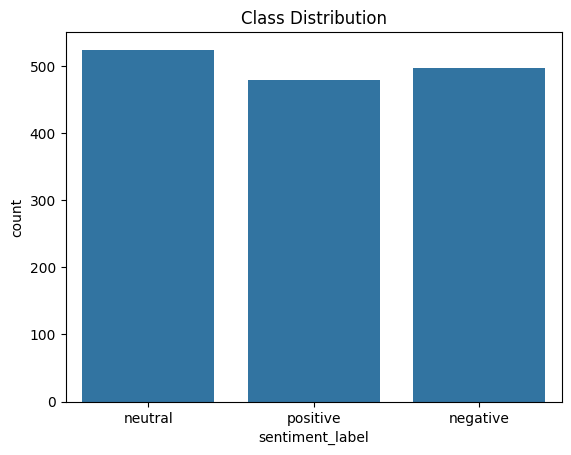

In [8]:
#Classic Distribution

print(df['sentiment_label'].value_counts())

sns.countplot(x='sentiment_label', data=df)
plt.title("Class Distribution")
plt.savefig("results/model_evaluation.png")
plt.show()

**Task-2: Text Preprocessing**

In [9]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['cleaned_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'cleaned_text']].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


**Task 3: Text Vectorization**

In [10]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_text'])

y = df['sentiment_label']

In [11]:
#Train-test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Task 4: Baseline Model**

In [12]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [13]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [14]:
#Classification Reort

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



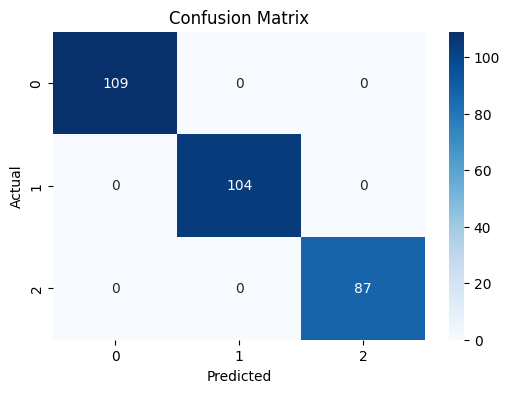

In [15]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [16]:
#Save Sample Prediction 

sample_output = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

sample_output.head(20).to_csv(
    "results/sample_predictions.txt",
    index=False
)

**Task 5: Sequence Model or Conceptual Architecture**

In [21]:
#Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

In [25]:
#Padding

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 100

X_seq = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print(X_seq.shape)

(1500, 100)


In [26]:
#Label encoding 

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [27]:
#Train-Test split 

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [28]:
# Build LSTM Model

lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_length),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 64)           320000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 3)                 99        
                                                                 
Total params: 355203 (1.35 MB)
Trainable params: 355203 (1.35 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [29]:
#Train LSTM Model

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5


30/30 [==============================] - 5s 64ms/step - loss: 1.0992 - accuracy: 0.3552 - val_loss: 1.0995 - val_accuracy: 0.3292
Epoch 2/5
30/30 [==============================] - 1s 30ms/step - loss: 1.0984 - accuracy: 0.3552 - val_loss: 1.0990 - val_accuracy: 0.3292
Epoch 3/5
30/30 [==============================] - 1s 28ms/step - loss: 1.0984 - accuracy: 0.3552 - val_loss: 1.0993 - val_accuracy: 0.3292
Epoch 4/5
30/30 [==============================] - 1s 29ms/step - loss: 1.0979 - accuracy: 0.3552 - val_loss: 1.1005 - val_accuracy: 0.3292
Epoch 5/5
30/30 [==============================] - 1s 30ms/step - loss: 1.0988 - accuracy: 0.3365 - val_loss: 1.0991 - val_accuracy: 0.3292


In [30]:
#Evaluate LSTM

loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("LSTM Accuracy:", accuracy)

10/10 [==============================] - 0s 15ms/step - loss: 1.0982 - accuracy: 0.3467
LSTM Accuracy: 0.3466666638851166


Architecture Explanation
Input Sequence

The customer message is converted into a sequence of token IDs.

Embedding Layer

Transforms each token into dense numerical vectors that capture semantic meaning.

LSTM Layer

Processes text sequentially and remembers important information from earlier words.

Output Layer

Uses Softmax activation to predict positive, neutral, or negative sentiment.

Loss Function

L=−∑ylog(y^)
Sparse categorical cross-entropy measures prediction error for multiclass classification.

Evaluation Metric

Accuracy=
Total Predictions
Correct Predictions
	​


Accuracy evaluates how many predictions were classified correctly.

**Task 6: Attention and Transformer Reflection**

**Why RNNs Struggle with Long-Term Dependencies?**

RNNs process information sequentially, but during long sequences they gradually forget earlier information because of vanishing gradients.

**How LSTMs Help**?

LSTMs use memory cells and gating mechanisms to retain important information for longer periods, improving sequence understanding.

**What Attention Solves?**

Attention allows the model to focus on the most relevant words in the input sequence instead of compressing all information into a single hidden state.

**Why Transformers Are Important?**

Transformers process all words in parallel and use self-attention to understand relationships between words efficiently. They power modern NLP systems like GPT, BERT, and Generative AI applications because they train faster and capture context better than traditional RNNs.